# Figure 2 - Brownian Motion vs Gradient Descent

This notebook reproduces the Section 4.2 case study on the true-label MNIST classification MDP.  The reusable MLP and true-label MDP live in `src.models.mlp` and `configs.environments.easy_mdp`; this notebook keeps the run broken into inspectable steps.

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_ROOT = ROOT / "data"
OUTPUT_ROOT = ROOT / "outputs"
FIGURES_DIR = OUTPUT_ROOT / "figures"
TABLES_DIR = OUTPUT_ROOT / "tables"
CHECKPOINTS_DIR = OUTPUT_ROOT / "checkpoints"
for directory in (OUTPUT_ROOT, FIGURES_DIR, TABLES_DIR, CHECKPOINTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)
MPLCONFIGDIR = OUTPUT_ROOT / "matplotlib_cache"
MPLCONFIGDIR.mkdir(exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

ROOT

PosixPath('/Users/mahdigheidi/Documents/Univ/Masters-Study-Project')

In [2]:
import copy
import random
from typing import Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans
from torchvision import datasets, transforms
from tqdm import tqdm

from src.environments.easy_mdp import EasyMDP
from src.models.mlp import MLP
from src.agents.replay_buffer import ReplayBuffer

from src.pyhessian import Hessian
from src.pyhessian.density_plot import get_esd_plot

In [3]:
seed: int = 3273892
data_root: str = str(DATA_ROOT)
download: bool = True
hidden_dim: int = 512
gamma: float = 0.99
lr: float = 1e-3
batch_size: int = 512
replay_capacity: int = 10_000
prefill_steps: int = 5_000
train_steps: int = 5_000
target_update_period: int = 5_000
epsilon: float = 0.1
probe_batch_size: int = 512
cov_batch_size: int = 512
esd_points: int = 600

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# use mps on mac
# device = torch.device("mps" if torch.backends.mps.is_available() else device)
device

device(type='cpu')

In [5]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(seed)
print(f"Seed set to {seed}")

Seed set to 3273892


In [6]:
class QNetwork(MLP):
    def __init__(self, hidden_dim: int = 512):
        super().__init__(input_shape=(1, 28, 28), num_actions=10, hidden_dim=hidden_dim)

In [7]:
# load the data and create the environment
transform = transforms.ToTensor()
dataset = datasets.MNIST(
    root=data_root,
    train=True,
    download=download,
    transform=transform,
)

In [8]:
env = EasyMDP(dataset, seed=seed)

In [9]:
replay = ReplayBuffer(capacity=replay_capacity)


@torch.no_grad()
def select_action(model: QNetwork, obs: torch.Tensor, epsilon: float) -> int:
    if random.random() < epsilon:
        return random.randrange(10)

    q_values = model(obs.unsqueeze(0).to(device))
    return int(q_values.argmax(dim=1).item())


def collect_transition(
    env: EasyMDP,
    model: QNetwork,
    replay: ReplayBuffer,
    epsilon: float,
) -> None:
    state = int(env.state)
    obs = env.sample_observation(state)
    action = select_action(model, obs, epsilon)
    next_obs, reward, _ = env.step(action)
    replay.push(obs.cpu(), action, reward, next_obs.cpu())


In [10]:
gd_model = QNetwork(hidden_dim).to(device)
bm_model = copy.deepcopy(gd_model).to(device)
target_model = copy.deepcopy(gd_model).to(device)

In [11]:
# print weights and biases of the model
for name, param in gd_model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

fc1.weight tensor([[ 0.0032,  0.0067,  0.0348,  ..., -0.0333,  0.0178,  0.0222],
        [-0.0113, -0.0175, -0.0325,  ...,  0.0247,  0.0114, -0.0185],
        [-0.0290, -0.0093,  0.0287,  ..., -0.0214,  0.0299, -0.0054],
        ...,
        [-0.0242, -0.0208,  0.0334,  ...,  0.0331,  0.0329, -0.0143],
        [ 0.0264,  0.0292,  0.0297,  ..., -0.0059,  0.0042, -0.0288],
        [-0.0291, -0.0308, -0.0244,  ...,  0.0321,  0.0288, -0.0090]])
fc1.bias tensor([ 2.1066e-02,  3.2061e-04, -3.2164e-02,  1.9357e-02, -1.9564e-02,
        -1.5694e-02, -3.1996e-02, -1.5231e-02,  1.0368e-02,  6.0105e-03,
        -2.1330e-02,  3.2528e-02,  3.3737e-02, -1.1974e-02,  1.2510e-02,
         8.4283e-03, -1.8892e-02,  2.9463e-03,  5.6039e-03, -2.9613e-02,
        -2.2803e-02,  5.6058e-03,  1.4792e-03,  3.3726e-03, -2.7542e-02,
        -9.4261e-03, -8.3434e-03, -1.9976e-02, -6.3995e-03, -2.4083e-02,
        -1.8890e-02,  5.6573e-03, -1.0773e-02, -3.2315e-02, -6.2785e-03,
        -1.2226e-02, -9.5804e-03,  

In [12]:
# prefill the replay buffer
print("Prefilling replay buffer...")
for _ in tqdm(range(prefill_steps)):
    collect_transition(env, gd_model, replay, epsilon)

Prefilling replay buffer...


  0%|          | 0/5000 [00:00<?, ?it/s]

 29%|██▉       | 1449/5000 [00:00<00:00, 14486.56it/s]

 63%|██████▎   | 3148/5000 [00:00<00:00, 15955.84it/s]

 98%|█████████▊| 4923/5000 [00:00<00:00, 16771.82it/s]

100%|██████████| 5000/5000 [00:00<00:00, 16373.37it/s]

In [13]:
def make_probe_targets(
    model: QNetwork,
    inputs: torch.Tensor,
    noise: Optional[torch.Tensor] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        if noise is None:
            noise = torch.randn_like(outputs)
        return (outputs + noise).detach(), noise.detach()

In [14]:
def probe_criterion(pred, target):
    return ((pred - target) ** 2).sum() / pred.shape[0]

In [15]:
# plot the hessian esd at initialization
probe_batch = replay.sample(512)
probe_targets, _ = make_probe_targets(gd_model, probe_batch[0])
hessian = Hessian(
    model=gd_model,
    data=(probe_batch[0], probe_targets),
    criterion=F.mse_loss,
    cuda=False,
)
eig, weight = hessian.density(iter=100, n_v=10)

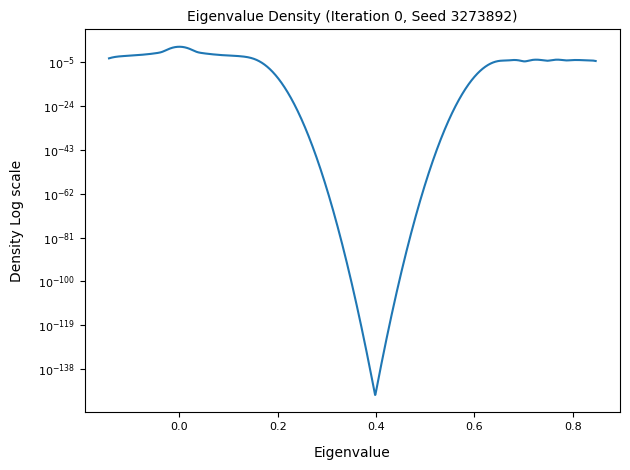

In [16]:
get_esd_plot(eig, weight, 0, seed, out_dir=str(FIGURES_DIR / "esd"))

## Sanity Check the Shared Components

Before running the long loop, instantiate the shared MLP and true-label MDP, then step the environment once.

## Run the Experiment

The run couples two trajectories from the same initialization: one follows SGD on the Q-learning objective, and the other receives Brownian parameter perturbations with the same update norm.

In [17]:
optimizer = torch.optim.SGD(gd_model.parameters(), lr=lr)

In [18]:
def q_learning_loss(
    model: QNetwork,
    target_model: QNetwork,
    batch: Tuple[torch.Tensor, ...],
    gamma: float,
) -> torch.Tensor:
    states, actions, rewards, next_states = batch
    states = states.to(device)
    actions = actions.to(device)
    rewards = rewards.to(device)
    next_states = next_states.to(device)

    q_sa = model(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    with torch.no_grad():
        next_q = target_model(next_states).max(dim=1).values
        td_target = rewards + gamma * next_q

    return F.mse_loss(q_sa, td_target)

In [19]:
def sgd_step_and_update_norm(
    model: QNetwork,
    target_model: QNetwork,
    optimizer: torch.optim.Optimizer,
    batch: Tuple[torch.Tensor, ...],
    gamma: float,
    lr: float,
) -> Tuple[float, float]:
    model.train()
    loss = q_learning_loss(model, target_model, batch, gamma)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()

    update_norm_sq = torch.zeros((), device=device)
    for p in model.parameters():
        if p.grad is not None:
            update_norm_sq += (lr * p.grad).pow(2).sum()

    optimizer.step()
    return float(loss.detach().cpu().item()), float(update_norm_sq.sqrt().cpu().item())


@torch.no_grad()
def brownian_step(model: QNetwork, step_norm: float) -> None:
    if step_norm <= 0:
        return

    noise = [torch.randn_like(p) for p in model.parameters()]
    total_norm = torch.sqrt(sum((n * n).sum() for n in noise))
    scale = step_norm / (float(total_norm.item()) + 1e-12)

    for p, n in zip(model.parameters(), noise):
        p.add_(n * scale)

In [20]:
@torch.no_grad()
def evaluate_policy(
    model: QNetwork,
    env: EasyMDP,
    num_samples: int = 1024,
) -> float:
    model.eval()
    correct = 0

    for _ in range(num_samples):
        state = random.randrange(10)
        obs = env.sample_observation(state)
        pred = model(obs.unsqueeze(0).to(device)).argmax(dim=1).item()
        correct += int(pred == state)

    return correct / float(num_samples)

In [21]:
for step in tqdm(range(1, 10000 + 1)):

    collect_transition(env, gd_model, replay, epsilon=epsilon)

    batch = replay.sample(batch_size)
    loss, update_norm = sgd_step_and_update_norm(
        gd_model,
        target_model,
        optimizer,
        batch,
        gamma,
        lr,
    )
    brownian_step(bm_model, update_norm)

    if step % target_update_period == 0:
        # save a snapshot of the current model parameters to the checkpoint directory
        torch.save(gd_model.state_dict(), CHECKPOINTS_DIR / f"hessian_step_{step}.pt")
        target_model.load_state_dict(gd_model.state_dict())
        target_update = step // target_update_period
        accuracy = evaluate_policy(gd_model, env, num_samples=1024)
        log_row = {
            "step": float(step),
            "target_update": float(target_update),
            "loss": float(loss),
            "update_norm": float(update_norm),
            "accuracy": float(accuracy),
        }
        print(
            "target update "
            f"{int(log_row['target_update'])}: "
            f"step={step}, loss={loss:.4f}, "
            f"update_norm={update_norm:.5f}, accuracy={accuracy:.3f}"
        )

  0%|          | 0/10000 [00:00<?, ?it/s]

  0%|          | 9/10000 [00:00<01:51, 89.38it/s]

  0%|          | 20/10000 [00:00<01:42, 97.23it/s]

  0%|          | 32/10000 [00:00<01:34, 105.88it/s]

  0%|          | 44/10000 [00:00<01:31, 109.39it/s]

...

100%|█████████▉| 9973/10000 [01:31<00:00, 105.44it/s]

100%|█████████▉| 9984/10000 [01:31<00:00, 100.24it/s]

100%|█████████▉| 9995/10000 [01:31<00:00, 95.44it/s] 

100%|██████████| 10000/10000 [01:31<00:00, 108.79it/s]

target update 2: step=10000, loss=0.0693, update_norm=0.00012, accuracy=0.219


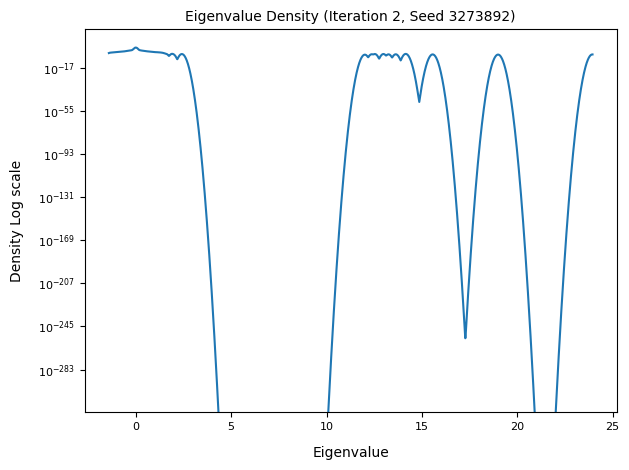

In [22]:
probe_batch = replay.sample(512)
probe_targets, _ = make_probe_targets(gd_model, probe_batch[0])
hessian = Hessian(
    model=gd_model,
    data=(probe_batch[0], probe_targets),
    criterion=probe_criterion,
    cuda=False,
)
eig, weight = hessian.density(iter=100, n_v=10)
get_esd_plot(eig, weight, 2, seed, out_dir=str(FIGURES_DIR / "esd"))

In [23]:
--- PACKAGE THIS INTO A PYTHON FILE ---
-- ALSO THE HESSIAN CODE ---
-- ADD AN ITER ON THE TITLE --

from typing import List
def probe_loss_from_targets(
    model: QNetwork,
    inputs: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    return F.mse_loss(model(inputs.to(device)), targets.to(device))


def flat_parameters(model: nn.Module) -> List[torch.nn.Parameter]:
    return [p for p in model.parameters() if p.requires_grad]


def flat_grad_from_loss(
    model: QNetwork,
    loss: torch.Tensor,
    create_graph: bool,
) -> torch.Tensor:
    grads = torch.autograd.grad(
        loss,
        flat_parameters(model),
        create_graph=create_graph,
        retain_graph=create_graph,
    )
    return torch.cat([g.reshape(-1) for g in grads])


def sample_probe_gradient(
    model: QNetwork,
    x: torch.Tensor,
    target: torch.Tensor,
) -> torch.Tensor:
    model.zero_grad(set_to_none=True)
    loss = probe_loss_from_targets(
        model,
        x.unsqueeze(0),
        target.unsqueeze(0),
    )
    grad = flat_grad_from_loss(model, loss, create_graph=False).detach().cpu()
    model.zero_grad(set_to_none=True)
    return grad



def gradient_covariance(
    model: QNetwork,
    inputs: torch.Tensor,
    targets: torch.Tensor,
    k: int,
) -> np.ndarray:
    model.eval()
    k = min(k, inputs.size(0))

    grads = []
    for i in range(k):
        grad = sample_probe_gradient(model, inputs[i], targets[i])
        grad = grad / grad.norm().clamp(min=1e-12)
        grads.append(grad)

    grad_matrix = torch.stack(grads)
    cov = grad_matrix @ grad_matrix.T
    return cov.numpy()


def reorder_by_kmeans(cov: np.ndarray, clusters: int = 10) -> np.ndarray:
    clusters = min(clusters, cov.shape[0])
    labels = KMeans(n_clusters=clusters, random_state=0, n_init=10).fit_predict(cov)
    order = np.argsort(labels)
    return cov[order][:, order]

SyntaxError: invalid syntax (2668928105.py, line 1)

In [24]:
probe_batch = replay.sample(cov_batch_size)
probe_targets, _ = make_probe_targets(gd_model, probe_batch[0])
cov_gd = gradient_covariance(gd_model, probe_batch[0], probe_targets, k=cov_batch_size)
cov_bm = gradient_covariance(bm_model, probe_batch[0], probe_targets, k=cov_batch_size)

# reorder the covariance matrices by kmeans clustering
cov_gd = reorder_by_kmeans(cov_gd, clusters=10)
cov_bm = reorder_by_kmeans(cov_bm, clusters=10)

NameError: name 'gradient_covariance' is not defined

NameError: name 'cov_gd' is not defined

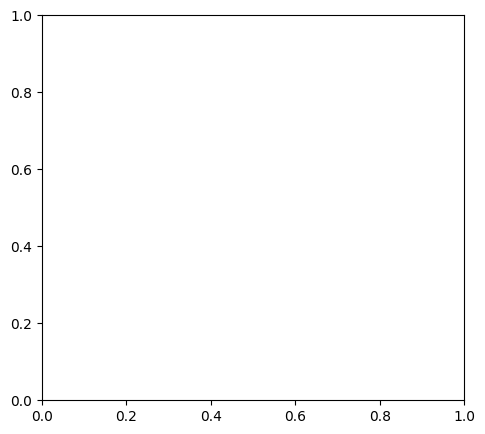

In [25]:
# plot the covariance matrices
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cov_gd, cmap="coolwarm_r", vmin=-1, vmax=1, aspect="equal")
plt.title("Gradient Covariance (GD)", fontsize=14)
plt.subplot(1, 2, 2)
plt.imshow(cov_bm, cmap="coolwarm_r", vmin=-1, vmax=1, aspect="equal")
plt.title("Gradient Covariance (BM)", fontsize=14)
plt.show()